# Experiment: Playground Series S6E5 PitNextLap EDA + Baseline

Objective:
- Understand the competition data with targeted EDA.
- Build a leak-safe validation setup grouped by race.
- Compare a fast baseline against a stronger model.
- Train the best model on all training data and write `submission.csv`.


## Plan

- Audit shapes, dtypes, missingness, and target balance.
- Check leakage candidates and define a safe validation split.
- Engineer a small set of race-aware features.
- Fit a logistic baseline and a stronger tree-based model.
- Inspect error patterns and export a submission file.


In [1]:
from __future__ import annotations

import random
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from IPython.display import display

from sklearn.base import BaseEstimator, ClassifierMixin, clone
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import log_loss, roc_auc_score
from sklearn.model_selection import GroupKFold, StratifiedGroupKFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, StandardScaler

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
warnings.filterwarnings("ignore")

sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 140)

DATA_DIR = Path.cwd()
TRAIN_PATH = DATA_DIR / "train.csv"
TEST_PATH = DATA_DIR / "test.csv"
SAMPLE_SUB_PATH = DATA_DIR / "sample_submission.csv"

TARGET = "PitNextLap"
ID_COL = "id"
RENAME_MAP = {"LapTime (s)": "LapTime_s"}

try:
    from catboost import CatBoostClassifier

    HAS_CATBOOST = True
except Exception:
    CatBoostClassifier = None
    HAS_CATBOOST = False

print(f"Working directory: {DATA_DIR}")
print(f"CatBoost available: {HAS_CATBOOST}")


Working directory: c:\Users\adief\OneDrive\Dokumen\Project\Predicting F1 Pit Stops
CatBoost available: True


## Load Data

The notebook is local-first, so paths are resolved relative to the current working directory.


In [2]:
train_raw = pd.read_csv(TRAIN_PATH).rename(columns=RENAME_MAP)
test_raw = pd.read_csv(TEST_PATH).rename(columns=RENAME_MAP)
sample_sub = pd.read_csv(SAMPLE_SUB_PATH)

assert TARGET in train_raw.columns
assert TARGET not in test_raw.columns
assert list(sample_sub.columns) == [ID_COL, TARGET]
assert train_raw[ID_COL].is_unique
assert test_raw[ID_COL].is_unique
assert train_raw[TARGET].isin([0, 1]).all()

print(f"train shape: {train_raw.shape}")
print(f"test shape: {test_raw.shape}")
print(f"sample submission shape: {sample_sub.shape}")
display(train_raw.head(3))


train shape: (439140, 16)
test shape: (188165, 15)
sample submission shape: (188165, 2)


,id,Driver,Compound,Race,Year,PitStop,LapNumber,Stint,TyreLife,Position,LapTime_s,LapTime_Delta,Cumulative_Degradation,RaceProgress,Position_Change,PitNextLap
0,0,D109,HARD,Canadian Grand Prix,2022,0,50,2,39.0,8,78.491,-7.564,21.019,0.714286,5.0,1.0
1,1,D086,HARD,Dutch Grand Prix,2025,1,27,2,7.0,4,75.095,-32.617,-223.207,0.346154,-3.0,0.0
2,2,ZON,HARD,Austrian Grand Prix,2022,0,59,3,22.0,13,70.945,-7.540,-100.529,0.819444,3.0,1.0


## Data Audit

We want a quick view of the dataset before we model it:
- column types
- missingness
- uniqueness for the high-value categorical columns
- target imbalance


In [3]:
def overview(df: pd.DataFrame, name: str) -> pd.DataFrame:
    summary = pd.DataFrame(
        {
            "dtype": df.dtypes.astype(str),
            "missing_pct": (df.isna().mean() * 100).round(3),
            "nunique": df.nunique(dropna=False),
        }
    ).sort_values(["missing_pct", "nunique"], ascending=[False, False])
    print(f"{name}: {df.shape[0]:,} rows x {df.shape[1]} columns")
    display(summary)
    return summary


train_overview = overview(train_raw, "train")
test_overview = overview(test_raw, "test")

target_summary = (
    train_raw[TARGET]
    .value_counts()
    .rename("count")
    .to_frame()
    .assign(rate=lambda d: d["count"] / len(train_raw))
)
display(target_summary)

key_cols = ["Driver", "Compound", "Race", "Year", "PitStop"]
display(train_raw[key_cols].nunique().rename("nunique").to_frame())

numeric_cols = [
    "LapNumber",
    "Stint",
    "TyreLife",
    "Position",
    "LapTime_s",
    "LapTime_Delta",
    "Cumulative_Degradation",
    "RaceProgress",
    "Position_Change",
]
corr_to_target = (
    train_raw[numeric_cols + [TARGET]]
    .corr(numeric_only=True)[TARGET]
    .drop(TARGET)
    .sort_values(key=lambda s: s.abs(), ascending=False)
)
display(corr_to_target.to_frame("pearson_corr_to_target"))

print("Train-only columns:", sorted(set(train_raw.columns) - set(test_raw.columns)))
print("Test-only columns:", sorted(set(test_raw.columns) - set(train_raw.columns)))


train: 439,140 rows x 16 columns


,dtype,missing_pct,nunique
id,int64,0.0,439140
Cumulative_Degradation,float64,0.0,142701
LapTime_Delta,float64,0.0,57532
LapTime_s,float64,0.0,37719
RaceProgress,float64,0.0,1898
Driver,object,0.0,887
LapNumber,int64,0.0,78
TyreLife,float64,0.0,78
Position_Change,float64,0.0,37
Race,object,0.0,26


test: 188,165 rows x 15 columns


,dtype,missing_pct,nunique
id,int64,0.0,188165
Cumulative_Degradation,float64,0.0,86823
LapTime_Delta,float64,0.0,40673
LapTime_s,float64,0.0,30286
RaceProgress,float64,0.0,1556
Driver,object,0.0,801
LapNumber,int64,0.0,77
TyreLife,float64,0.0,77
Position_Change,float64,0.0,37
Race,object,0.0,26


,count,rate
PitNextLap,,
0.0,351759,0.801018
1.0,87381,0.198982


,nunique
Driver,887
Compound,5
Race,26
Year,4
PitStop,2


,pearson_corr_to_target
TyreLife,0.273510
LapNumber,0.267057
Stint,0.198193
RaceProgress,0.185477
Cumulative_Degradation,-0.167401
Position_Change,0.046230
LapTime_s,-0.034096
Position,0.021348
LapTime_Delta,-0.004946


Train-only columns: ['PitNextLap']
Test-only columns: []


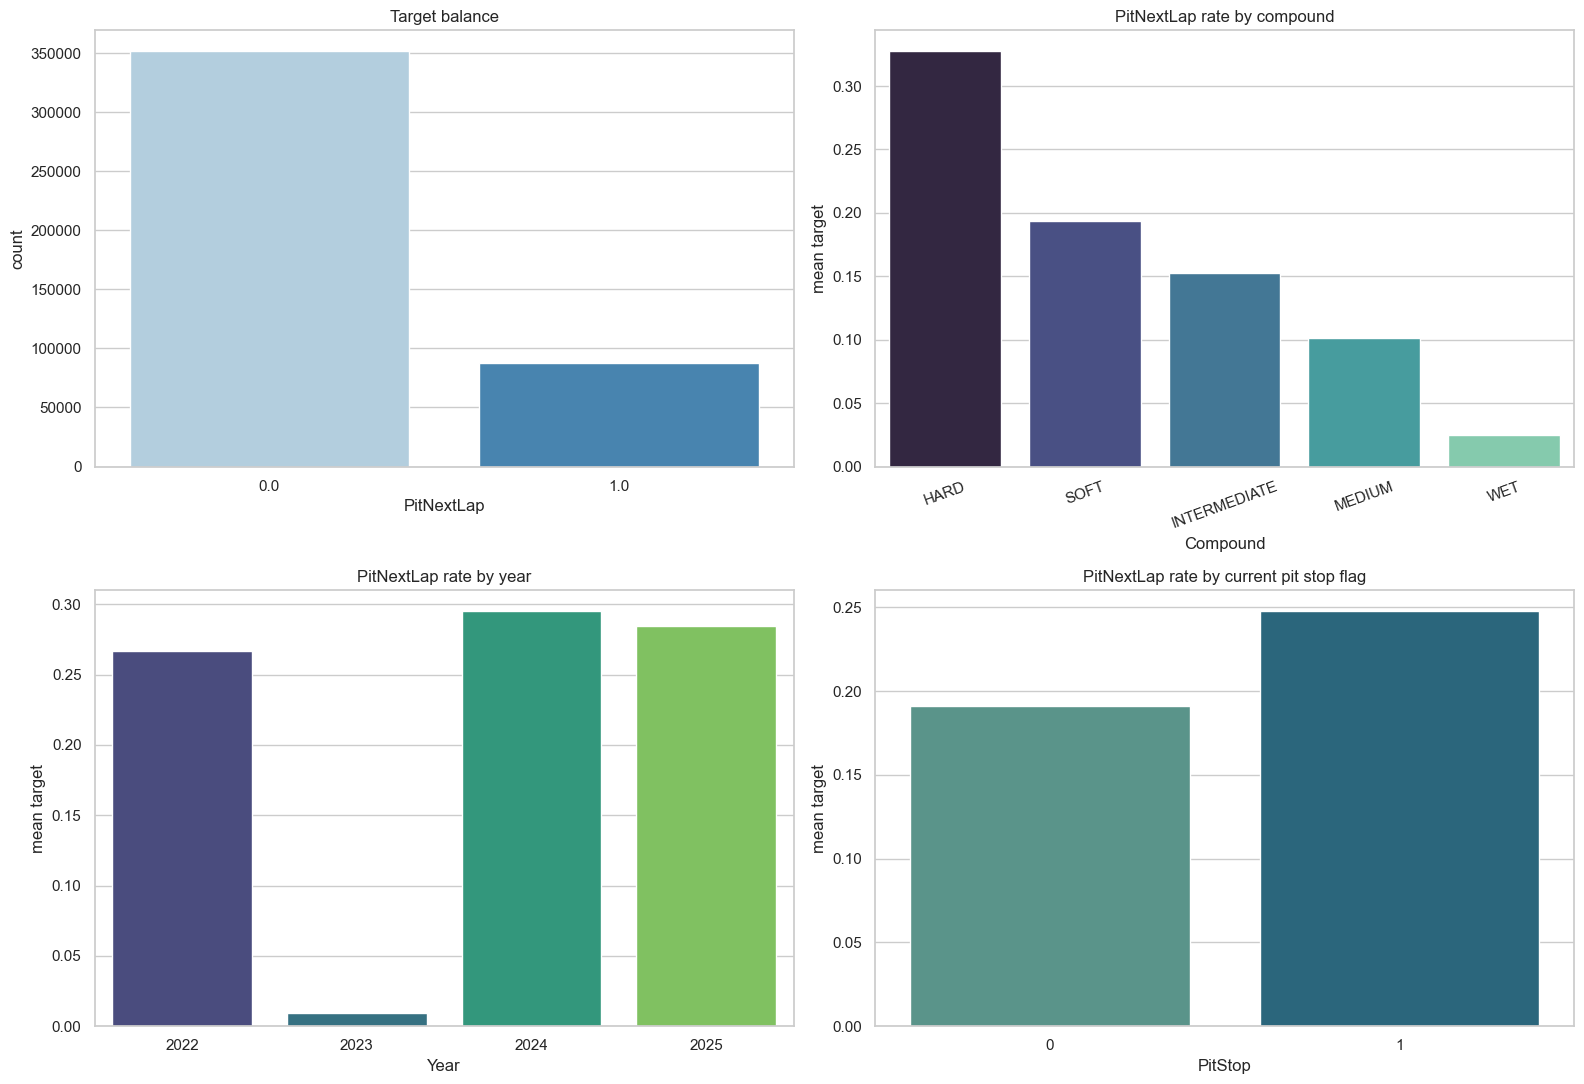

,mean,count
Race,,
Chinese Grand Prix,0.388593,7311
Monaco Grand Prix,0.357398,21539
Spanish Grand Prix,0.319973,20483
Bahrain Grand Prix,0.287535,19535
Belgian Grand Prix,0.280382,9002
Emilia Romagna Grand Prix,0.272557,15483
French Grand Prix,0.257457,3185
São Paulo Grand Prix,0.253718,11497


,mean,count
Race,,
Abu Dhabi Grand Prix,0.150545,16427
Pre-Season Testing,0.146541,22492
Singapore Grand Prix,0.141772,18960
British Grand Prix,0.133459,15383
Italian Grand Prix,0.131963,19854
United States Grand Prix,0.114048,18045
Miami Grand Prix,0.103552,18860
Mexico City Grand Prix,0.090656,23672


In [4]:
target_rate_by_compound = train_raw.groupby("Compound")[TARGET].agg(["mean", "count"]).sort_values("mean", ascending=False)
target_rate_by_year = train_raw.groupby("Year")[TARGET].agg(["mean", "count"]).sort_index()
target_rate_by_race = train_raw.groupby("Race")[TARGET].agg(["mean", "count"]).sort_values("mean", ascending=False)
target_rate_by_pitstop = train_raw.groupby("PitStop")[TARGET].agg(["mean", "count"]).sort_index()

fig, axes = plt.subplots(2, 2, figsize=(16, 11))

target_counts = train_raw[TARGET].value_counts().sort_index()
sns.barplot(
    x=target_counts.index.astype(str),
    y=target_counts.values,
    ax=axes[0, 0],
    palette="Blues",
)
axes[0, 0].set_title("Target balance")
axes[0, 0].set_xlabel("PitNextLap")
axes[0, 0].set_ylabel("count")

sns.barplot(
    x=target_rate_by_compound.index,
    y=target_rate_by_compound["mean"].values,
    ax=axes[0, 1],
    palette="mako",
)
axes[0, 1].set_title("PitNextLap rate by compound")
axes[0, 1].set_xlabel("Compound")
axes[0, 1].set_ylabel("mean target")
axes[0, 1].tick_params(axis="x", rotation=20)

sns.barplot(
    x=target_rate_by_year.index.astype(str),
    y=target_rate_by_year["mean"].values,
    ax=axes[1, 0],
    palette="viridis",
)
axes[1, 0].set_title("PitNextLap rate by year")
axes[1, 0].set_xlabel("Year")
axes[1, 0].set_ylabel("mean target")

sns.barplot(
    x=target_rate_by_pitstop.index.astype(str),
    y=target_rate_by_pitstop["mean"].values,
    ax=axes[1, 1],
    palette="crest",
)
axes[1, 1].set_title("PitNextLap rate by current pit stop flag")
axes[1, 1].set_xlabel("PitStop")
axes[1, 1].set_ylabel("mean target")

plt.tight_layout()
plt.show()

display(target_rate_by_race.head(8))
display(target_rate_by_race.tail(8))


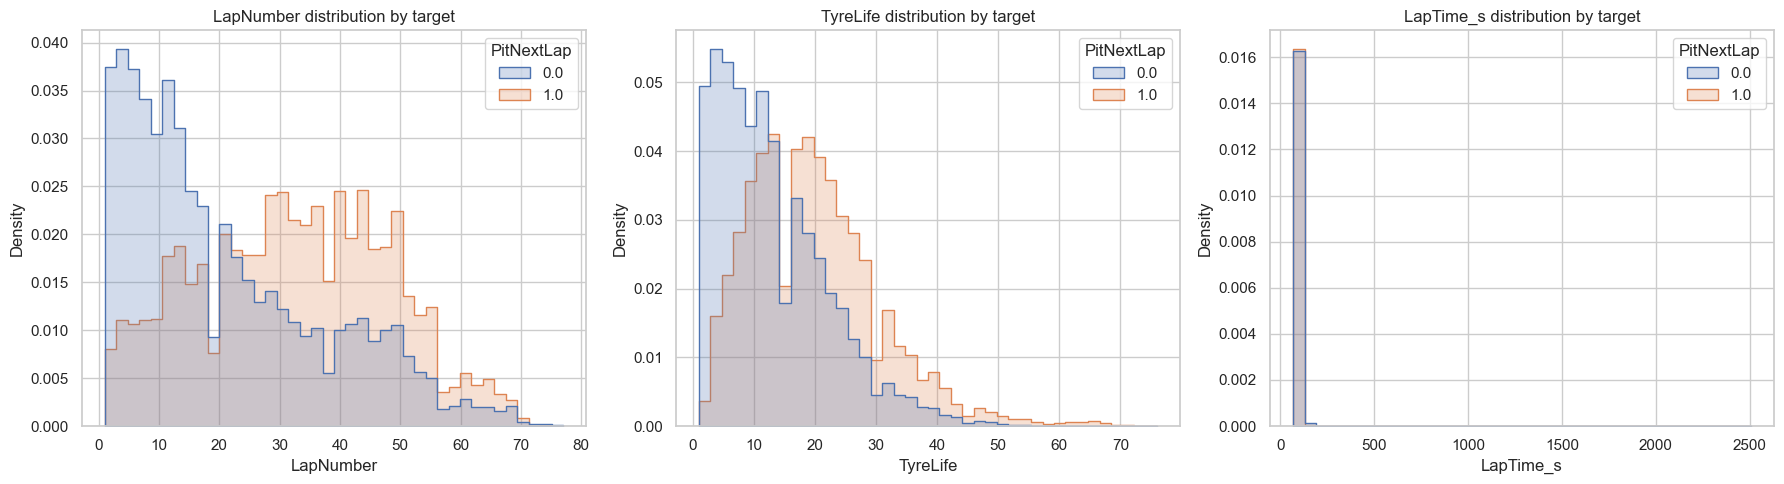

In [5]:
plot_df = train_raw.sample(n=min(50000, len(train_raw)), random_state=SEED)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, col in zip(axes, ["LapNumber", "TyreLife", "LapTime_s"]):
    sns.histplot(
        data=plot_df,
        x=col,
        hue=TARGET,
        bins=40,
        stat="density",
        common_norm=False,
        element="step",
        ax=ax,
    )
    ax.set_title(f"{col} distribution by target")

plt.tight_layout()
plt.show()


## Leakage and Validation

- `id` stays out of the model.
- `Race` is used as a group key so the same race does not leak across folds.
- `Year` stays as a feature, but the split is grouped by race rather than by row.


In [6]:
def engineer_features(df: pd.DataFrame) -> pd.DataFrame:
    out = df.copy()

    out["Year"] = out["Year"].astype(str)
    out["LapTime_Delta_abs"] = out["LapTime_Delta"].abs()
    out["Position_Change_abs"] = out["Position_Change"].abs()
    out["Cumulative_Degradation_abs"] = out["Cumulative_Degradation"].abs()
    out["TyreLife_per_LapNumber"] = out["TyreLife"] / out["LapNumber"].clip(lower=1)
    out["LapNumber_per_TyreLife"] = out["LapNumber"] / out["TyreLife"].clip(lower=1)
    out["RaceProgress_x_TyreLife"] = out["RaceProgress"] * out["TyreLife"]
    out["RaceProgress_x_LapNumber"] = out["RaceProgress"] * out["LapNumber"]
    out["LapTime_per_TyreLife"] = out["LapTime_s"] / out["TyreLife"].clip(lower=1)
    out["Is_Late_Race"] = (out["RaceProgress"] >= 0.75).astype(int)
    out["Is_New_Tyre"] = (out["TyreLife"] <= 2).astype(int)
    out["Is_CompWetOrInter"] = out["Compound"].isin(["INTERMEDIATE", "WET"]).astype(int)

    return out


def make_cv(n_splits: int = 5):
    try:
        return StratifiedGroupKFold(n_splits=n_splits, shuffle=True, random_state=SEED)
    except Exception:
        return GroupKFold(n_splits=n_splits)


class CatBoostWrapper(BaseEstimator, ClassifierMixin):
    def __init__(
        self,
        cat_features=None,
        iterations: int = 250,
        depth: int = 6,
        learning_rate: float = 0.08,
        random_seed: int = SEED,
    ):
        self.cat_features = cat_features
        self.iterations = iterations
        self.depth = depth
        self.learning_rate = learning_rate
        self.random_seed = random_seed

    def fit(self, X, y):
        if not HAS_CATBOOST:
            raise ImportError("CatBoost is not available in this environment.")

        self.model_ = CatBoostClassifier(
            iterations=self.iterations,
            depth=self.depth,
            learning_rate=self.learning_rate,
            loss_function="Logloss",
            eval_metric="AUC",
            auto_class_weights="Balanced",
            random_seed=self.random_seed,
            verbose=False,
            allow_writing_files=False,
            thread_count=-1,
        )
        fit_kwargs = {}
        if self.cat_features is not None:
            fit_kwargs["cat_features"] = self.cat_features
        self.model_.fit(X, y, **fit_kwargs)
        self.classes_ = np.array([0, 1])
        return self

    def predict_proba(self, X):
        proba = self.model_.predict_proba(X)
        return np.asarray(proba)

    def predict(self, X):
        return (self.predict_proba(X)[:, 1] >= 0.5).astype(int)


train_fe = engineer_features(train_raw)
test_fe = engineer_features(test_raw)

feature_cols = [c for c in train_fe.columns if c not in {TARGET, ID_COL}]
categorical_cols = ["Driver", "Compound", "Race", "Year"]
numeric_cols = [c for c in feature_cols if c not in categorical_cols]

X = train_fe[feature_cols].copy()
y = train_fe[TARGET].astype(int).copy()
groups = train_fe["Race"].copy()
X_test = test_fe[feature_cols].copy()

assert set(categorical_cols).issubset(X.columns)
assert ID_COL not in X.columns

cv = make_cv(n_splits=5)

print(f"Model features: {len(feature_cols)} total -> {len(numeric_cols)} numeric, {len(categorical_cols)} categorical")
print(f"Unique races: {train_fe['Race'].nunique()}")


Model features: 25 total -> 21 numeric, 4 categorical
Unique races: 26


In [7]:
baseline_preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            Pipeline(
                steps=[
                    ("imputer", SimpleImputer(strategy="median")),
                    ("scaler", StandardScaler(with_mean=False)),
                ]
            ),
            numeric_cols,
        ),
        (
            "cat",
            Pipeline(
                steps=[
                    ("imputer", SimpleImputer(strategy="most_frequent")),
                    ("ohe", OneHotEncoder(handle_unknown="ignore")),
                ]
            ),
            categorical_cols,
        ),
    ],
    remainder="drop",
    sparse_threshold=0.3,
)

baseline_model = Pipeline(
    steps=[
        ("preprocess", baseline_preprocessor),
        (
            "clf",
            LogisticRegression(
                solver="saga",
                max_iter=2000,
                n_jobs=-1,
                class_weight="balanced",
                random_state=SEED,
            ),
        ),
    ]
)


def evaluate_cv(estimator, X_df, y_series, groups_series, cv_obj, model_name: str):
    oof = np.zeros(len(X_df), dtype=float)
    fold_rows = []

    for fold, (tr_idx, va_idx) in enumerate(cv_obj.split(X_df, y_series, groups_series), start=1):
        X_tr, X_va = X_df.iloc[tr_idx], X_df.iloc[va_idx]
        y_tr, y_va = y_series.iloc[tr_idx], y_series.iloc[va_idx]

        fitted = clone(estimator)
        fitted.fit(X_tr, y_tr)
        proba = fitted.predict_proba(X_va)[:, 1]

        oof[va_idx] = proba
        fold_rows.append(
            {
                "model": model_name,
                "fold": fold,
                "rows": len(va_idx),
                "roc_auc": roc_auc_score(y_va, proba),
                "logloss": log_loss(y_va, np.clip(proba, 1e-6, 1 - 1e-6)),
            }
        )

    fold_df = pd.DataFrame(fold_rows)
    summary = {
        "model": model_name,
        "roc_auc_oof": roc_auc_score(y_series, oof),
        "logloss_oof": log_loss(y_series, np.clip(oof, 1e-6, 1 - 1e-6)),
    }
    return oof, fold_df, summary


baseline_oof, baseline_folds, baseline_summary = evaluate_cv(
    baseline_model,
    X,
    y,
    groups,
    cv,
    model_name="logistic",
)

display(baseline_folds)
display(pd.DataFrame([baseline_summary]).set_index("model"))


,model,fold,rows,roc_auc,logloss
0,logistic,1,99218,0.903422,0.457049
1,logistic,2,80494,0.903204,0.479790
2,logistic,3,84383,0.865739,0.489588
3,logistic,4,84914,0.872688,0.558817
4,logistic,5,90131,0.909026,0.397142


,roc_auc_oof,logloss_oof
model,,
logistic,0.891395,0.474853


In [8]:
if HAS_CATBOOST:
    strong_model = CatBoostWrapper(
        cat_features=categorical_cols,
        iterations=250,
        depth=6,
        learning_rate=0.08,
        random_seed=SEED,
    )
    strong_name = "catboost"
else:
    strong_preprocessor = ColumnTransformer(
        transformers=[
            (
                "num",
                Pipeline(
                    steps=[
                        ("imputer", SimpleImputer(strategy="median")),
                    ]
                ),
                numeric_cols,
            ),
            (
                "cat",
                Pipeline(
                    steps=[
                        ("imputer", SimpleImputer(strategy="most_frequent")),
                        (
                            "ordinal",
                            OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1),
                        ),
                    ]
                ),
                categorical_cols,
            ),
        ],
        remainder="drop",
    )

    strong_model = Pipeline(
        steps=[
            ("preprocess", strong_preprocessor),
            (
                "clf",
                HistGradientBoostingClassifier(
                    max_depth=6,
                    learning_rate=0.06,
                    max_iter=250,
                    random_state=SEED,
                ),
            ),
        ]
    )
    strong_name = "hist_gradient_boosting"


strong_oof, strong_folds, strong_summary = evaluate_cv(
    strong_model,
    X,
    y,
    groups,
    cv,
    model_name=strong_name,
)

display(strong_folds)
display(pd.DataFrame([strong_summary]).set_index("model"))


,model,fold,rows,roc_auc,logloss
0,catboost,1,99218,0.927723,0.376538
1,catboost,2,80494,0.923356,0.384743
2,catboost,3,84383,0.913243,0.397234
3,catboost,4,84914,0.917295,0.298877
4,catboost,5,90131,0.937148,0.304818


,roc_auc_oof,logloss_oof
model,,
catboost,0.920037,0.352282


In [9]:
leaderboard = (
    pd.DataFrame([baseline_summary, strong_summary])
    .set_index("model")
    .sort_values("logloss_oof")
)
display(leaderboard)

winner_name = leaderboard.index[0]
winner_oof = baseline_oof if winner_name == "logistic" else strong_oof
winner_model = baseline_model if winner_name == "logistic" else strong_model

print(f"Selected model: {winner_name}")


,roc_auc_oof,logloss_oof
model,,
catboost,0.920037,0.352282
logistic,0.891395,0.474853


Selected model: catboost


In [10]:
final_model = clone(winner_model)
final_model.fit(X, y)
test_proba = final_model.predict_proba(X_test)[:, 1]

submission = sample_sub.copy()
submission[TARGET] = test_proba
submission.to_csv("submission.csv", index=False)

assert len(submission) == len(test_raw)
assert list(submission.columns) == [ID_COL, TARGET]

print("submission.csv saved")
print(submission[TARGET].describe())
display(submission.head())


submission.csv saved
count    188165.000000
mean          0.306495
std           0.361297
min           0.000517
25%           0.014625
50%           0.084038
75%           0.680925
max           0.989703
Name: PitNextLap, dtype: float64


,id,PitNextLap
0,439140,0.014448
1,439141,0.011260
2,439142,0.012918
3,439143,0.400584
4,439144,0.923672


OOF ROC AUC: 0.92004
OOF LogLoss: 0.35228


,Race,rows,target_rate,mean_pred,mae
10,Emilia Romagna Grand Prix,15483,0.272557,0.506940,0.326119
11,French Grand Prix,3185,0.257457,0.441031,0.272469
9,Dutch Grand Prix,24462,0.176069,0.381242,0.261289
4,Bahrain Grand Prix,19535,0.287535,0.417590,0.259363
16,Mexico City Grand Prix,23672,0.090656,0.296957,0.252761
24,São Paulo Grand Prix,11497,0.253718,0.375066,0.251422
23,Spanish Grand Prix,20483,0.319973,0.321700,0.250474
7,Canadian Grand Prix,21416,0.153857,0.326510,0.248648
2,Austrian Grand Prix,21223,0.188051,0.333603,0.230810
12,Hungarian Grand Prix,22481,0.239269,0.374225,0.225591


,Compound,rows,target_rate,mean_pred,mae
1,INTERMEDIATE,17382,0.152284,0.341183,0.282723
0,HARD,170518,0.327537,0.462488,0.254329
3,SOFT,38744,0.193475,0.275805,0.223615
4,WET,1355,0.025092,0.198508,0.199570
2,MEDIUM,211141,0.101131,0.214961,0.175169


,Year,rows,target_rate,mean_pred,mae
0,2022,82989,0.266505,0.434318,0.295633
2,2024,127110,0.295319,0.453952,0.292901
3,2025,92894,0.284389,0.445120,0.283876
1,2023,136147,0.009607,0.044366,0.044556


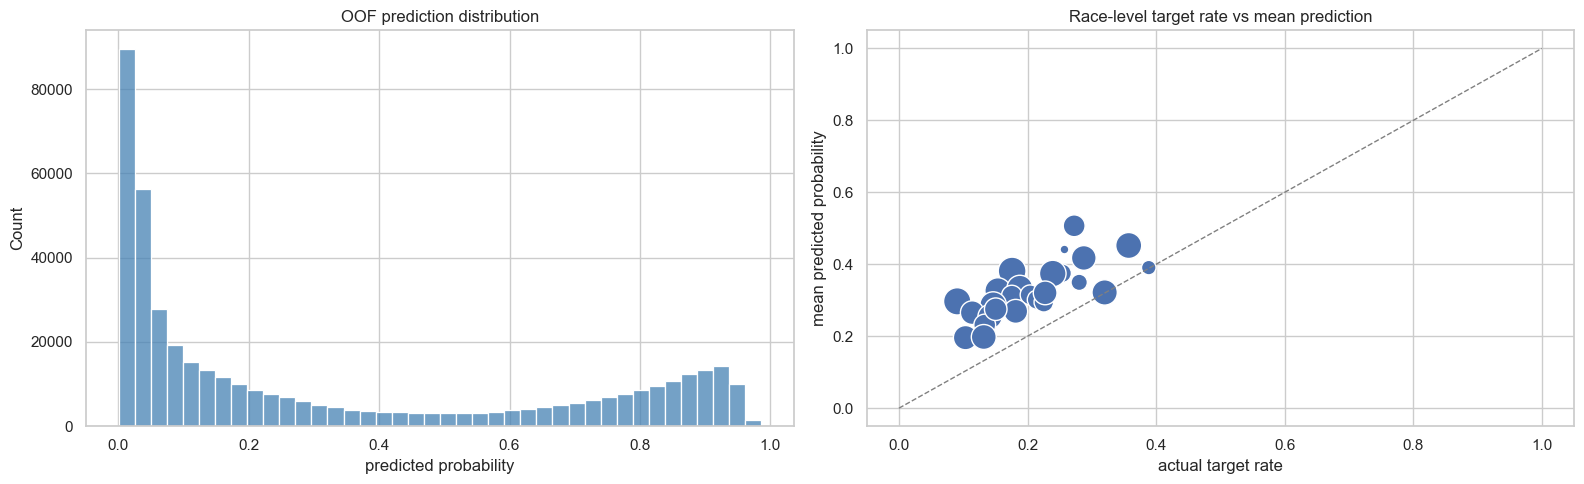

In [11]:
oof_frame = train_raw[[ID_COL, "Driver", "Compound", "Race", "Year", TARGET]].copy()
oof_frame["oof_proba"] = winner_oof
oof_frame["pred_label"] = (oof_frame["oof_proba"] >= 0.5).astype(int)
oof_frame["abs_error"] = (oof_frame[TARGET] - oof_frame["oof_proba"]).abs()

print(f"OOF ROC AUC: {roc_auc_score(y, winner_oof):.5f}")
print(f"OOF LogLoss: {log_loss(y, np.clip(winner_oof, 1e-6, 1 - 1e-6)):.5f}")

error_by_race = (
    oof_frame.groupby("Race", as_index=False)
    .agg(
        rows=(ID_COL, "size"),
        target_rate=(TARGET, "mean"),
        mean_pred=("oof_proba", "mean"),
        mae=("abs_error", "mean"),
    )
    .sort_values("mae", ascending=False)
)
error_by_compound = (
    oof_frame.groupby("Compound", as_index=False)
    .agg(
        rows=(ID_COL, "size"),
        target_rate=(TARGET, "mean"),
        mean_pred=("oof_proba", "mean"),
        mae=("abs_error", "mean"),
    )
    .sort_values("mae", ascending=False)
)
error_by_year = (
    oof_frame.groupby("Year", as_index=False)
    .agg(
        rows=(ID_COL, "size"),
        target_rate=(TARGET, "mean"),
        mean_pred=("oof_proba", "mean"),
        mae=("abs_error", "mean"),
    )
    .sort_values("mae", ascending=False)
)

display(error_by_race.head(10))
display(error_by_compound)
display(error_by_year)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
sns.histplot(oof_frame["oof_proba"], bins=40, ax=axes[0], color="steelblue")
axes[0].set_title("OOF prediction distribution")
axes[0].set_xlabel("predicted probability")

sns.scatterplot(
    data=error_by_race,
    x="target_rate",
    y="mean_pred",
    size="rows",
    sizes=(40, 400),
    ax=axes[1],
    legend=False,
)
axes[1].plot([0, 1], [0, 1], linestyle="--", color="gray", linewidth=1)
axes[1].set_title("Race-level target rate vs mean prediction")
axes[1].set_xlabel("actual target rate")
axes[1].set_ylabel("mean predicted probability")

plt.tight_layout()
plt.show()


## Results and Next Steps

- Keep iterating on race-aware feature engineering if the OOF log loss is still improving.
- Try more careful leakage checks if a single feature looks too predictive.
- When you want a stronger submission, increase CatBoost iterations or try a deeper race-level feature pass.
